In [1]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
import pandas as pd
from cloudy_fit_lib import *
from scipy.interpolate import RegularGridInterpolator
import pickle
import corner
from scipy import integrate, interpolate
import emcee

In [2]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

In [3]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/cloudy_grids/'

Obtain the UVB grid from FG20

In [4]:
fg20_z_grid, fg20_wav_grid, fg20_J_nu_grid = read_uvb('', 'fg20_galaxy.ascii')

Fetch the SED at $z=1$

In [5]:
z_test = 1

In [6]:
fg20_J_nu_test = fetch_sed(z_test, fg20_z_grid, fg20_J_nu_grid)

Specify $N_{\mathrm{HI}}$ grid points and get corresponding filenames

In [7]:
logN_HI_min = 12
logN_HI_max = 17
logN_HI_step = 0.25

logN_HI_arr = np.arange(logN_HI_min, logN_HI_max+logN_HI_step, logN_HI_step)

In [8]:
file_list = create_grid_file_list(logN_HI_arr)

Specify grid points for densities and metallicities

In [9]:
log_hdens_min = -5
log_hdens_max = 1
log_hdens_step = 0.25

log_hdens_arr = np.arange(log_hdens_min, log_hdens_max+log_hdens_step, log_hdens_step)
logU_arr = np.log10(calc_U(fg20_wav_grid, fg20_J_nu_test, 10**log_hdens_arr))

In [10]:
log_metals_min = -3
log_metals_max = 1
log_metals_step = 0.25

log_metals_arr = np.arange(log_metals_min, log_metals_max+log_metals_step, log_metals_step)

Load the final grid

In [11]:
pkl_file = open(rootdir+'final_grid.pkl', 'rb')
species_logN_samples = pickle.load(pkl_file)
pkl_file.close()

Interpolate this grid

In [12]:
species_logN_interp = {}

for s in list(species_logN_samples.keys()):
    
    species_logN_samples[s][species_logN_samples[s]==-np.inf] = -99
    
    species_logN_interp[s] = RegularGridInterpolator((logN_HI_arr, log_hdens_arr, log_metals_arr), 
                                                     species_logN_samples[s])

Enter measurements for species

In [15]:
logN_dict = {'HI':'15.40, -0.06, +0.06',
            'CII':'<13.46',
            'CIII':'13.97, -0.03, +0.03',
            'CIV':'13.73, -0.05, +0.05',
            'NII':'<13.23',
            'NIII':'<13.42',
            'NV':'<13.72',
            'OII':'<13.29',
            'OIII':'14.42, -0.02, +0.02',
            'OIV':'14.95, -0.03, +0.03',
            'NeVIII':'<13.35',
            'MgII':'<11.52',
            'AlIII':'<12.29',
            'SiII':'<13.27',
            'SiIII':'<12.77',
            'SVI':'<12.79',
            'FeII':'<11.90'}

Plot column densities

In [17]:
logN_HI_test = 15.40
log_hdens_test = -3.3
log_metals_test = -0.6

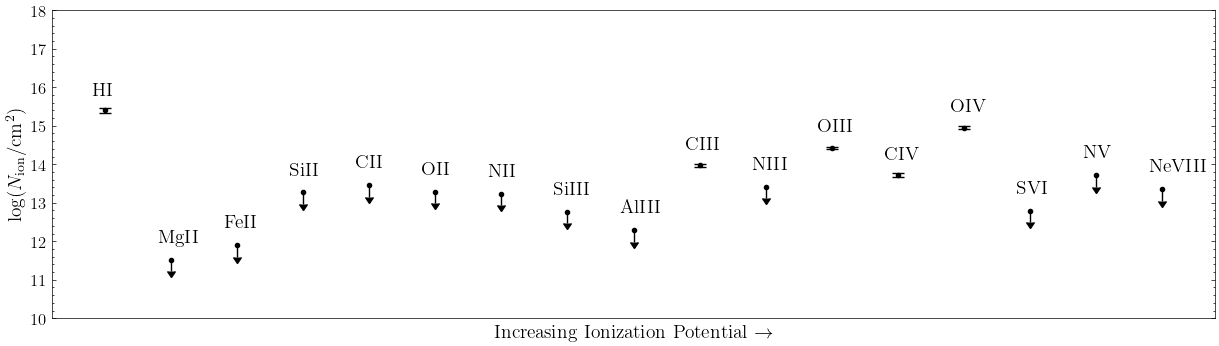

In [16]:
fig, ax = plot_column_densities_obs(logN_dict)